In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import palava
import os
#import statsmodels.api as sm

import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib
from scipy.ndimage import median_filter
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import igraph as ig


/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/site-packages/palava/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/site-packages/palava/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [2]:
# Helper fucntions

def print_list(my_list):
  print("[", ", ".join(f"'{item}'" for item in my_list), "]")

def median_smooth_rows(arr, window_size=11):
    # Apply median filtering to each row of the array
    smoothed = np.apply_along_axis(lambda x: median_filter(x, size=window_size), axis=0, arr=arr)
    return smoothed




# Helper functions for the plots
def sort_based_on_first_row(matrix):
    sorted_indices = np.argsort(-matrix[0])
    # Rearrange the columns based on the sorted indices
    sorted_matrix = matrix[:, sorted_indices]
    return  sorted_matrix



def plot_multiple_ranks(data, colors=None, labels_offset=0.05, arrow_len=0, y_spacing=1, 
                        draw_uncolored_edges=True, title='', show_uncolored_nodes=True, 
                        color_legend=None, label_updates=None):
    """
    Plots ranked lists with connections and optional coloring, legend, and label updates.

    Parameters:
    - data: dict
        A dictionary where keys are list names and values are ranked lists.
    - colors: dict, optional
        A dictionary mapping items to colors.
    - labels_offset: float, optional
        Horizontal offset for text labels.
    - arrow_len: float, optional
        Arrowhead length for connections.
    - y_spacing: float, optional
        Vertical spacing between nodes.
    - draw_uncolored_edges: bool, optional
        Whether to draw edges for uncolored nodes.
    - title: str, optional
        Title for the plot.
    - show_uncolored_nodes: bool, optional
        Whether to display labels for uncolored nodes.
    - color_legend: dict, optional
        A dictionary mapping colors to legend labels (e.g., {'red': 'Beta', 'green': 'Delta'}).
    - label_updates: dict, optional
        A dictionary mapping old labels to new labels (e.g., {'gene2': 'GATA2'}).
    """
   
    keys = list(data.keys())  # Extract the keys from the dictionary
    num_lists = len(keys)  # Number of input lists
    fig, ax = plt.subplots(figsize=(17.5, 5))

    ax.set_xlim(0, num_lists + 1)  # Adjust x-limits based on the number of lists
    max_len = max(len(lst) for lst in data.values())  # Find the longest list for y-axis limits

    # Reverse the order of each list
    reversed_data = {key: lst[::-1] for key, lst in data.items()}

    # Calculate y-values for each reversed list
    y_values = [np.arange(1, len(reversed_data[key]) * y_spacing + 1, y_spacing) for key in keys]
    ax.set_ylim(0, max(len(lst) * y_spacing for lst in reversed_data.values()) + y_spacing)  # Set y-limits

    ax.axis('off')  # Remove axes

    # Draw arrows between the lists
    for i in range(num_lists - 1):  # Loop through each adjacent pair of lists
        current_list = reversed_data[keys[i]]
        next_list = reversed_data[keys[i + 1]]

        # Create a mapping from current list to next list
        current_to_next = [next_list.index(item) if item in next_list else None for item in current_list]

        for j in range(len(current_list)):
            if current_to_next[j] is not None:
                # Determine the color for the edge based on the current node color
                edge_color = colors.get(current_list[j], 'black') if colors else 'black'

                # Check if we should skip drawing this edge
                if edge_color == 'black' and not draw_uncolored_edges:
                    continue

                # Draw the arrow with the corresponding edge color
                ax.arrow(i + 1.02, y_values[i][j], 
                         0.96, y_values[i + 1][current_to_next[j]] - y_values[i][j], 
                         head_width=arrow_len, head_length=arrow_len, 
                         fc=edge_color, ec=edge_color, length_includes_head=True, linestyle=':', alpha=0.5)

    # Plot points for each reversed list
    for i, key in enumerate(keys):
        lst = reversed_data[key]
        for j in range(len(lst)):
            # Default to black for the points
            ax.plot(i + 1, y_values[i][j], 'o', markersize=2, color='black')  # Points
            
            # Determine the color for each gene, defaulting to black if not found
            text_color = colors.get(lst[j], 'black') if colors else 'black'
            
            # Update the label using label_updates if provided
            label = label_updates.get(lst[j], lst[j]) if label_updates else lst[j]
            
            # Show the node name only if the color is specified or if show_uncolored_nodes is True
            if text_color != 'black' or show_uncolored_nodes:
                ax.text(i + 1 - labels_offset, y_values[i][j], label, 
                        verticalalignment='center', horizontalalignment='right', color=text_color, fontsize=12)

        # Add key label at the bottom of each column
        ax.text(i + 1, -0.5, key, verticalalignment='top', horizontalalignment='center', fontsize=15)

    # Add title
    plt.title(title, fontsize=15)

    # Add legend if color_legend is provided
    if color_legend:
        legend_patches = [mpatches.Patch(color=color, label=label) for color, label in color_legend.items()]
        ax.legend(handles=legend_patches, loc='upper right', fontsize=12.5, title="Legend", bbox_to_anchor=(0.40, 0., 0.5, 0.6))

    plt.show()


def plot_multiple_ranks_supp(data, colors=None, labels_offset=0.1, arrow_len=0, y_spacing=1, 
                        draw_uncolored_edges=True, title='', show_uncolored_nodes=True, color_legend=None):
    """
    Plots ranked lists with connections and optional coloring and legend.
    
    Parameters:
    - data: dict
        A dictionary where keys are list names and values are ranked lists.
    - colors: dict, optional
        A dictionary mapping items to colors.
    - labels_offset: float, optional
        Horizontal offset for text labels.
    - arrow_len: float, optional
        Arrowhead length for connections.
    - y_spacing: float, optional
        Vertical spacing between nodes.
    - draw_uncolored_edges: bool, optional
        Whether to draw edges for uncolored nodes.
    - title: str, optional
        Title for the plot.
    - show_uncolored_nodes: bool, optional
        Whether to display labels for uncolored nodes.
    - color_legend: dict, optional
        A dictionary mapping colors to legend labels (e.g., {'red': 'Beta', 'green': 'Delta'}).
    """
    import numpy as np  # Import if not already in use
    import matplotlib.patches as mpatches  # For creating legend patches
    
    keys = list(data.keys())  # Extract the keys from the dictionary
    num_lists = len(keys)  # Number of input lists
    fig, ax = plt.subplots(figsize=(12.5, 17.5))
    
    ax.set_xlim(0, num_lists + 1)  # Adjust x-limits based on the number of lists
    max_len = max(len(lst) for lst in data.values())  # Find the longest list for y-axis limits
    
    # Reverse the order of each list
    reversed_data = {key: lst[::-1] for key, lst in data.items()}

    # Calculate y-values for each reversed list
    y_values = [np.arange(1, len(reversed_data[key]) * y_spacing + 1, y_spacing) for key in keys]
    ax.set_ylim(0, max(len(lst) * y_spacing for lst in reversed_data.values()) + y_spacing)  # Set y-limits
    
    ax.axis('off')  # Remove axes

    # Draw arrows between the lists
    for i in range(num_lists - 1):  # Loop through each adjacent pair of lists
        current_list = reversed_data[keys[i]]
        next_list = reversed_data[keys[i + 1]]
        
        # Create a mapping from current list to next list
        current_to_next = [next_list.index(item) if item in next_list else None for item in current_list]
        
        for j in range(len(current_list)):
            if current_to_next[j] is not None:
                # Determine the color for the edge based on the current node color
                edge_color = colors.get(current_list[j], 'black') if colors else 'black'
                
                # Check if we should skip drawing this edge
                if edge_color == 'black' and not draw_uncolored_edges:
                    continue
                
                # Draw the arrow with the corresponding edge color
                ax.arrow(i + 1.02, y_values[i][j], 
                         0.96, y_values[i + 1][current_to_next[j]] - y_values[i][j], 
                         head_width=arrow_len, head_length=arrow_len, 
                         fc=edge_color, ec=edge_color, length_includes_head=True, linestyle=':', alpha=0.25)

    # Plot points for each reversed list
    for i, key in enumerate(keys):
        lst = reversed_data[key]
        for j in range(len(lst)):
            # Default to black for the points
            ax.plot(i + 1, y_values[i][j], 'o', markersize=8, color='black')  # Points
            
            # Determine the color for each gene, defaulting to black if not found
            text_color = colors.get(lst[j], 'black') if colors else 'black'
            
            # Show the node name only if the color is specified or if show_uncolored_nodes is True
            if text_color != 'black' or show_uncolored_nodes:
                ax.text(i + 1 - labels_offset, y_values[i][j], lst[j], 
                        verticalalignment='center', horizontalalignment='right', color=text_color, fontsize=12.5)

        # Add key label at the bottom of each column
        ax.text(i + 1, -0.5, key, verticalalignment='top', horizontalalignment='center', fontsize=17.5)

    # Add title
    plt.title(title, fontsize=20)

    # Add legend if color_legend is provided
    if color_legend:
        legend_patches = [mpatches.Patch(color=color, label=label) for color, label in color_legend.items()]
        box = ax.get_position()
        ax.set_position([box.x0, box.y0 + box.height * 0.1,
                         box.width, box.height * 0.9])
        
        # Put a legend below current axis
        ax.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, -0.05),
              fancybox=True, shadow=True, ncol=5)
    
    plt.show()



def plot_gene_expression_pseudotime(adata, gene_symbols, pseudotime_column, color_column, zero_frac_to_remove_lst = None, order=None, colns=3, title='', fontsize =  15):
    """
    Plots gene expression vs. pseudotime for a list of genes, with a LOWESS curve (with customizable `frac`) and scatter plot colored by a specified column.
    Displays the plots in a grid format.

    Parameters:
    - adata: AnnData object containing gene expression data in `X` and metadata in `obs`.
    - gene_symbols: List of strings, gene symbols to plot the expression of.
    - pseudotime_column: String, column name in `obs` for pseudotime data.
    - color_column: String, column name in `obs` for color coding the scatter plot.
    - lowess_frac: List of floats, one LOWESS smoothing parameter for each gene in `gene_symbols`.
    - order: List or None, custom ordering of cell labels for coloring the plot. If None, the default order is used.
    - colns: Integer, number of columns in the grid of plots.
    - title: String, optional, overarching title for the grid of plots.
    """
    # Check if all gene_symbols exist in adata.var
    if zero_frac_to_remove_lst is None:
        zero_frac_to_remove_lst = [0.5] * len(gene_symbols)
    missing_genes = [gene for gene in gene_symbols if gene not in adata.var_names]
    if missing_genes:
        raise ValueError(f"Gene symbol(s) {missing_genes} not found in adata.var_names.")
    
    # Check if the number of lowess_frac values matches the number of genes
    if len(zero_frac_to_remove_lst) != len(gene_symbols):
        raise ValueError("The length of `zero_frac_to_remove_lst` must match the length of `gene_symbols`.")
    
    # Calculate the number of rows needed for the grid
    rows = -(-len(gene_symbols) // colns)  # Ceiling division to get number of rows
    
    # Create the grid of subplots
    fig, axes = plt.subplots(rows, colns, figsize=(colns * 5, rows * 3), constrained_layout=True)
    axes = axes.flatten()  # Flatten the axes array for easy indexing
    total_subplots = len(gene_symbols)

    # Number of plots in the last row
    last_row_subplots = total_subplots - (total_subplots % colns if total_subplots % colns != 0 else colns)
    # Loop through each gene and create a plot
    for idx, (gene_symbol, zero_frac_to_remove) in enumerate(zip(gene_symbols, zero_frac_to_remove_lst)):
        # Extract gene expression, pseudotime, and color data
        gene_idx = np.where(adata.var_names == gene_symbol)[0][0]
        gene_expression = adata.X[:, gene_idx].toarray().flatten() if hasattr(adata.X, 'toarray') else adata.X[:, gene_idx].flatten()
        pseudotime = adata.obs[pseudotime_column]
        color_data = adata.obs[color_column]
        
        gene_ind  = np.where(((gene_expression!=0) | np.random.binomial(1, 1.0 - zero_frac_to_remove, gene_expression.shape).astype(bool)))[0]
        gene_expression = gene_expression[gene_ind] 
        pseudotime = pseudotime[gene_ind]
        color_data = color_data[gene_ind]

        
        # If order is provided, reorder the color_data accordingly
        if order is not None:
            color_data = pd.Categorical(color_data, categories=order, ordered=True)
            
        # Create a dataframe for plotting
        df = pd.DataFrame({
            'gene_expression': gene_expression,
            'pseudotime': pseudotime,
            'color_data': color_data
        })

        # Plot scatterplot with custom order if specified
        ax = axes[idx]
        sns.scatterplot(
            x='pseudotime', 
            y='gene_expression', 
            hue='color_data', 
            data=df, 
            palette='bright', 
            s=5, 
            hue_order=order, 
            alpha=0.5, 
            ax=ax
        )
        
        # Fit and plot LOWESS curve with the specified smoothing parameter
        lowess = sm.nonparametric.lowess(df['gene_expression'], df['pseudotime'], frac = 0.15)
        ax.plot(lowess[:, 0], lowess[:, 1].clip(min = 0), color='black', linewidth=1, label='LOWESS')
        
        # Customize plot
        # ax.set_title(f'{gene_symbol} Expression')
        if idx >= last_row_subplots:
            ax.set_xlabel('Pseudotime', fontsize =fontsize) 
        else:  
            ax.set_xlabel('')
            
        ax.set_ylabel(f'{gene_symbol} Expression', fontsize = fontsize)
        if idx ==0 : ax.legend(markerscale = 5.0)
        else: ax.legend().remove()

    # Remove any unused axes if the number of genes < grid size
    for idx in range(len(gene_symbols), len(axes)):
        fig.delaxes(axes[idx])

    # Add an overarching title if provided
    if title:
        fig.suptitle(title, fontsize=16)
    
    plt.show()

def plot_pca_panels(adata, pc_pairs, figsize=(10, 8), color_by="cell.labels", main_title=None, fontsize = 20):
    """
    Plot PCA panels from an AnnData object.

    Parameters:
    -----------
    adata : AnnData
        The AnnData object containing PCA results.
    pc_pairs : list of str
        List of strings indicating which PCs to plot, e.g., ["1,2", "3,4"].
    figsize : tuple, optional
        Figure size for the plot (default: (10, 8)).
    color_by : str, optional
        Key in `adata.obs` to color the points (default: "cell.labels").
    main_title : str, optional
        Title for the entire figure (default: None).

    Returns:
    --------
    None
        Displays the plot.
    """
    # Check if PCA results are available
    if "X_pca" not in adata.obsm:
        raise ValueError("PCA results not found in `adata.obsm`. Ensure PCA has been computed.")
    
    # Extract PCA coordinates
    pca_coords = adata.obsm["X_pca"]
    
    # Prepare the figure
    n_panels = len(pc_pairs)
    n_rows = int(np.ceil(n_panels / 2))
    fig, axes = plt.subplots(n_rows, 2, figsize=figsize)
    axes = axes.flatten()

    # Determine if `color_by` is numeric or categorical
    if color_by in adata.obs:
        color_values = adata.obs[color_by]
        if pd.api.types.is_categorical_dtype(color_values):
            is_numeric = False
        else:
            is_numeric = np.issubdtype(color_values.dtype, np.number)
    else:
        raise ValueError(f"{color_by} not found in `adata.obs`.")
    
    # Loop through PC pairs and plot
    for idx, pc_pair in enumerate(pc_pairs):
        if idx >= len(axes):  # Stop if exceeding available axes
            break
        ax = axes[idx]
        pcs = [int(x) - 1 for x in pc_pair.split(",")]
        
        if is_numeric:
            # Scatter plot for the current PC pair with numeric color values
            scatter = ax.scatter(
                pca_coords[:, pcs[0]],
                pca_coords[:, pcs[1]],
                c=color_values,
                cmap="viridis",  # Color map for numeric data
                alpha=0.75,
                s=1,
                edgecolor='none'
            )
            cbar = fig.colorbar(scatter, ax=ax, pad=0.01)
            if idx < len(pc_pairs) - 1:
                cbar.remove()
            cbar.set_label('')
        else:
            # For categorical data, create a color palette
            palette = sns.color_palette("tab10", n_colors=len(color_values.cat.categories))
            cmap = ListedColormap(palette)  # Convert palette to ListedColormap
            scatter = ax.scatter(
                pca_coords[:, pcs[0]],
                pca_coords[:, pcs[1]],
                c=color_values.cat.codes,  # Convert categories to codes
                cmap=cmap,  # Use ListedColormap
                alpha=0.75,
                s=1,
                edgecolor='none'
            )
            ax.legend(*scatter.legend_elements(), title=color_by, loc='best', fontsize='small')
        
        ax.set_xlabel(f"PC{pcs[0] + 1}", fontsize=fontsize - 5)
        ax.set_ylabel(f"PC{pcs[1] + 1}", fontsize=fontsize - 5)

    # Hide unused subplots
    for idx in range(len(pc_pairs), len(axes)):
        fig.delaxes(axes[idx])
    
    # Add a main title if provided
    if main_title:
        fig.suptitle(main_title, fontsize=fontsize, y=0.95)

    plt.tight_layout()
    plt.show()


def scale_rows_zero_one(matrix):
    """
    Scales each row of a matrix to be between 0 and 1.
    
    Parameters:
        matrix (np.ndarray): Input 2D array.
    
    Returns:
        np.ndarray: Row-wise scaled matrix.
    """
    min_vals = matrix.min(axis=1, keepdims=True)
    max_vals = matrix.max(axis=1, keepdims=True)
    # Avoid division by zero
    scaled = (matrix - min_vals) / (max_vals - min_vals + 1e-8)
    return scaled


In [3]:


adata = sc.read('data/iPSC_with_pathways_cell_metadata_and_stages.h5ad') 
pathways = [torch.tensor(i) for i in adata.uns['pathways_9000hvg']]

adata


AnnData object with n_obs × n_vars = 36044 × 9000
    obs: 'cell_differentiation'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'pathway_names', 'pathways_9000hvg'
    obsm: 'PC1_top1000hvgs', 'PC1_top100hvgs', 'PC1_top2000hvgs', 'PC1_top200hvgs', 'PC1_top500hvgs', 'assigned', 'auxDir', 'cell_filter', 'cell_name', 'compatible_fragment_ratio', 'day', 'donor', 'donor_long_id', 'donor_short_id', 'expected_format', 'experiment', 'frag_dist_length', 'gc_bias_correct', 'is_cell_control', 'is_cell_control_bulk', 'is_cell_control_control', 'libType', 'library_types', 'log10_total_counts', 'log10_total_counts_ERCC', 'log10_total_counts_MT', 'log10_total_counts_endogenous', 'log10_total_counts_feature_control', 'log10_total_features', 'log10_total_features_ERCC', 'log10_total_features_MT', 'log10_total_features_endogenous', 'log10_total_features_feature_control', 'mapping_type', 'mates1', 'mates2', 'n_alt_reads', 'n_total_reads', 'num_

In [4]:
adata

AnnData object with n_obs × n_vars = 36044 × 9000
    obs: 'cell_differentiation'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'pathway_names', 'pathways_9000hvg'
    obsm: 'PC1_top1000hvgs', 'PC1_top100hvgs', 'PC1_top2000hvgs', 'PC1_top200hvgs', 'PC1_top500hvgs', 'assigned', 'auxDir', 'cell_filter', 'cell_name', 'compatible_fragment_ratio', 'day', 'donor', 'donor_long_id', 'donor_short_id', 'expected_format', 'experiment', 'frag_dist_length', 'gc_bias_correct', 'is_cell_control', 'is_cell_control_bulk', 'is_cell_control_control', 'libType', 'library_types', 'log10_total_counts', 'log10_total_counts_ERCC', 'log10_total_counts_MT', 'log10_total_counts_endogenous', 'log10_total_counts_feature_control', 'log10_total_features', 'log10_total_features_ERCC', 'log10_total_features_MT', 'log10_total_features_endogenous', 'log10_total_features_feature_control', 'mapping_type', 'mates1', 'mates2', 'n_alt_reads', 'n_total_reads', 'num_

In [5]:
sc.tl.pca(adata)

In [6]:
num_unann = int(40)

pathway_names = adata.uns['pathway_names']
num_ann = pathway_names.shape[0]
pathway_names_plot = [pathway_names[i].replace('_', ' ' ).capitalize() + ' ['+str(i)+']'  for i in range(len(pathway_names))] + ['Unannotated factor '+ str(i + 1) + ' ['+str(i+num_ann)+']'  for i in range(num_unann)]


In [7]:
SCVI_palava = palava.model.SCVI_palava
SCVI_palava.setup_anndata(adata, layer = 'counts')

/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/site-packages/palava/data/fields/_base_field.py:64: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [8]:
dr = 'Out_files_and_results/ipsc_data_9k/seed=0_lambda=0.4_lambda_marker_genes=0.1_palava_width=25_list_of_nonlin_factors=none'



In [9]:
SCVI_palava = palava.model.SCVI_palava
SCVI_palava.setup_anndata(adata, layer = 'counts')

/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/site-packages/palava/data/fields/_base_field.py:64: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [10]:
scvi_palava = SCVI_palava.load(file = dr+'/latent_and_slope_data/scvi_model', adata = adata)

factor_importance_dict  = np.load(dr + '/factor_importance_scores_dict.npy', allow_pickle=True)[()]
factor_importance = factor_importance_dict['factor_importance']

/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:168: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /home/ssanthoshkum/.local/lib/python3.10/site-pa ...
  rank_zero_warn(
/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/site-packages/palava/model/base/_utils.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipp

Number of latent variables = 94: 54 annotated + 40 unannotated


In [11]:
adata.obsm

AxisArrays with keys: PC1_top1000hvgs, PC1_top100hvgs, PC1_top2000hvgs, PC1_top200hvgs, PC1_top500hvgs, assigned, auxDir, cell_filter, cell_name, compatible_fragment_ratio, day, donor, donor_long_id, donor_short_id, expected_format, experiment, frag_dist_length, gc_bias_correct, is_cell_control, is_cell_control_bulk, is_cell_control_control, libType, library_types, log10_total_counts, log10_total_counts_ERCC, log10_total_counts_MT, log10_total_counts_endogenous, log10_total_counts_feature_control, log10_total_features, log10_total_features_ERCC, log10_total_features_MT, log10_total_features_endogenous, log10_total_features_feature_control, mapping_type, mates1, mates2, n_alt_reads, n_total_reads, num_assigned_fragments, num_bias_bins, num_bootstraps, num_compatible_fragments, num_consistent_mappings, num_inconsistent_mappings, num_libraries, num_mapped, num_processed, num_targets, nvars_used, pct_counts_ERCC, pct_counts_MT, pct_counts_endogenous, pct_counts_feature_control, pct_counts_

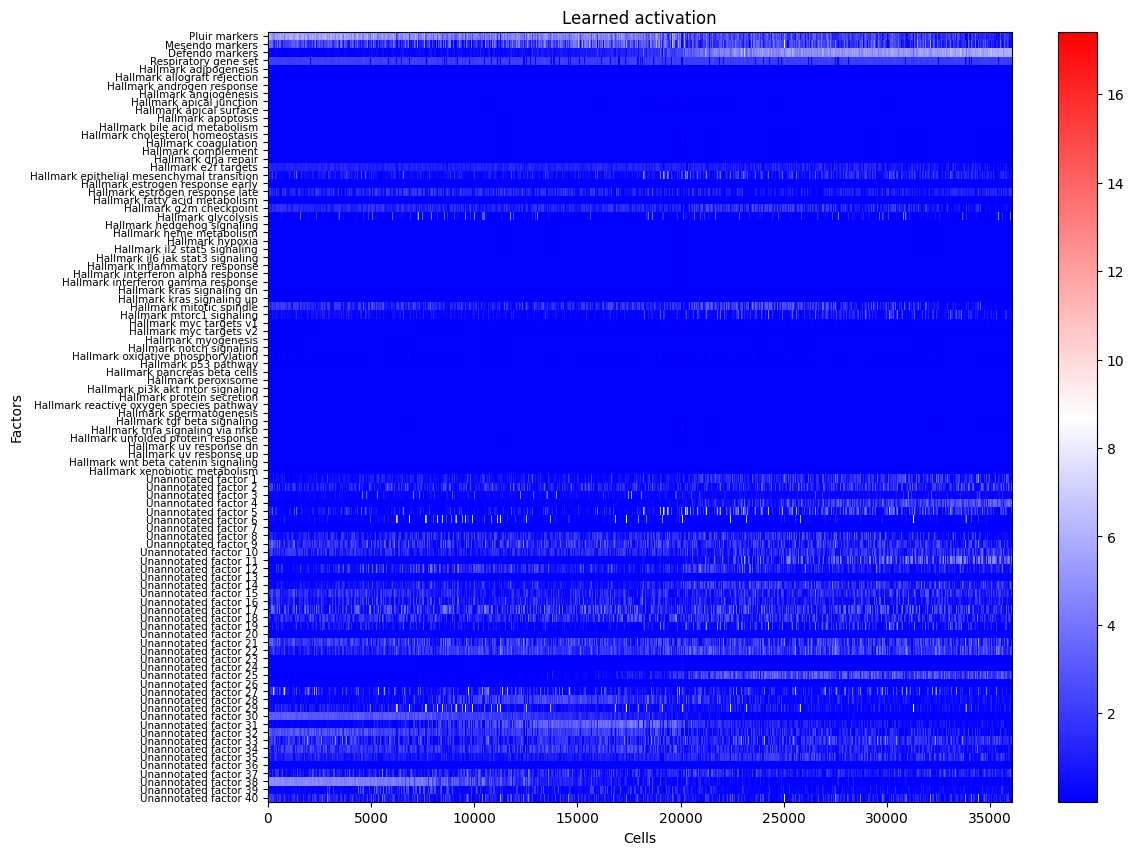

In [12]:
learned_activations = scvi_palava.get_latent_representation()


inds =np.argsort(adata.obsm['pseudo'])


pathway_names_plot_pres = [pathway_names[i].replace('_', ' ' ).capitalize()  for i in range(len(pathway_names))] + ['Unannotated factor '+ str(i + 1)   for i in range(num_unann)]

fig, ax = plt.subplots(figsize=(12, 10))

plt.imshow(learned_activations[inds,:].T,   aspect = 'auto', cmap='bwr', interpolation = 'none', rasterized=True)
plt.title("Learned activation")
plt.xlabel('Cells')
plt.ylabel('Factors')
_ = plt.yticks([i for i in range(len(pathway_names_plot_pres))], pathway_names_plot_pres, fontsize = 7.5)
cbar = plt.colorbar()
plt.show()
plt.close()




['Hallmark cholesterol homeostasis [12]']


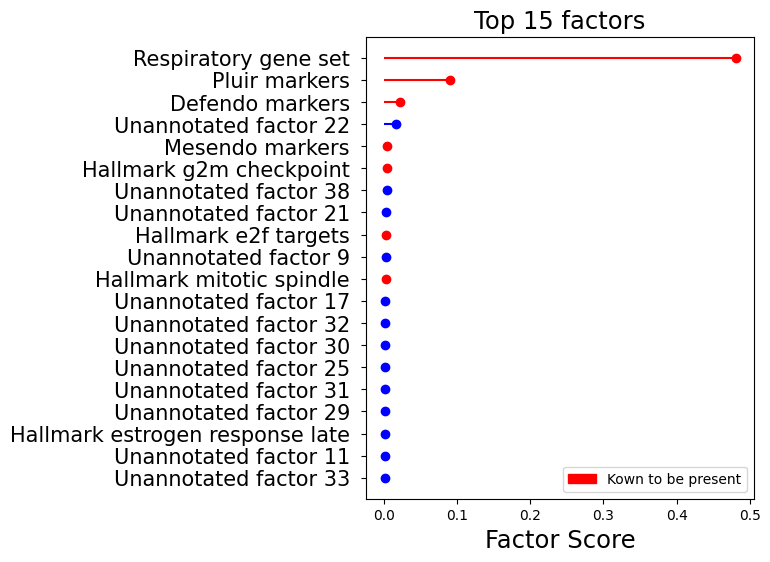

In [13]:

factor_importance_dict  = np.load(dr + '/factor_importance_scores_dict.npy', allow_pickle=True)[()]
factor_importance = factor_importance_dict['factor_importance'] #[:54]

highlighted_pathways =  ['Pluir markers [0]', 'Mesendo markers [1]', 'Defendo markers [2]','Respiratory gene set [3]', 'Hallmark e2f targets [16]', 'Hallmark cholesterol homeostasis [12]', 'Hallmark g2m checkpoint [21]','Hallmark mitotic spindle [33]']


index_asc_order = np.argsort(factor_importance)[::-1][:20][::-1]

print([x for x in highlighted_pathways if x not in np.array(pathway_names_plot)[index_asc_order]])

plt.figure(figsize=(5, 6))
for i, idx in enumerate(index_asc_order):
    pathway_name = pathway_names_plot[idx]
    color = 'r' if pathway_name in highlighted_pathways else 'b'
    plt.stem([pathway_name.split('[')[0]], [factor_importance[idx]], markerfmt=color+'o', linefmt=color+'-', orientation='horizontal')

plt.title('Top 15 factors', fontsize =17.5)
plt.xlabel('Factor Score', fontsize =17.5)
plt.tick_params(axis='y', which='major', labelsize=15)
            
red_patch = mpatches.Patch(color='red', label='Kown to be present')
blue_patch = mpatches.Patch(color='blue', label='Not known to be present')
plt.legend(handles=[red_patch], loc='lower right', title='')
plt.show()



In [14]:
np.argsort(factor_importance[:54])[::-1][:20]

array([ 3,  0,  2,  1, 21, 16, 33, 19, 17, 22, 34, 35, 48, 25, 39, 18, 36,
       13,  8,  4])

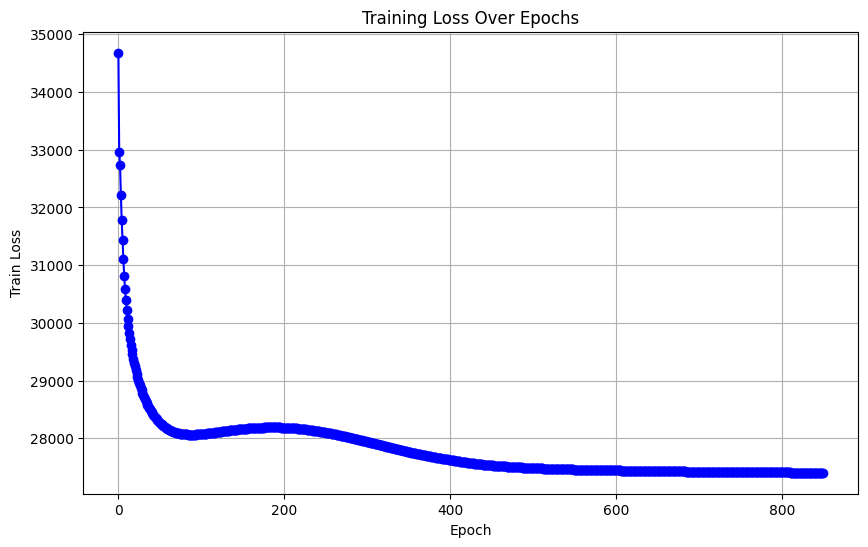

In [15]:

metric_to_plot = 'elbo_train'
df = scvi_palava.history[metric_to_plot]

plt.figure(figsize=(10, 6))

plt.plot(df.index, df[metric_to_plot], marker='o', linestyle='-', color='b')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.grid(True)
plt.show()

In [16]:

med_libsize = np.median(np.sum(adata.X, axis = 1))
print("Median library size is " + str(med_libsize))
adata_norm = sc.pp.normalize_per_cell(adata, counts_per_cell_after = med_libsize, copy = True)
adata_norm = sc.pp.log1p(adata_norm, copy = True)

sc.tl.pca(adata_norm, n_comps=6)

Median library size is 399785.88


In [17]:
adata.obsm["X_scVI"] = scvi_palava.get_latent_representation()


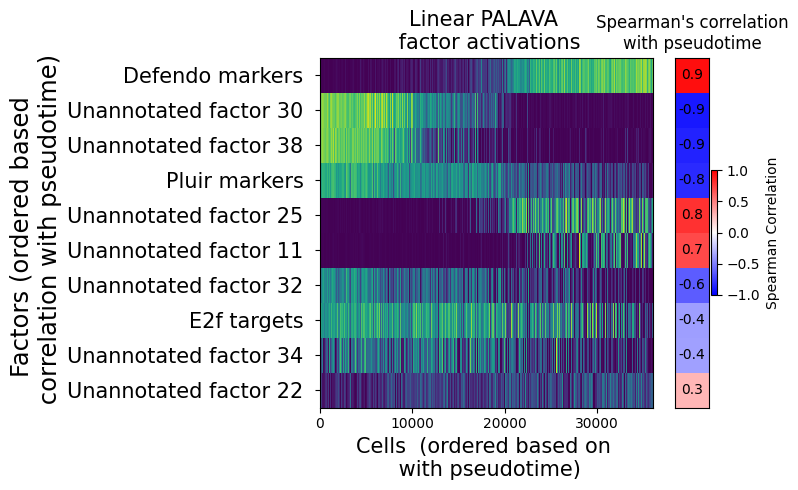

In [19]:

adata.obsm["X_scVI"] = scvi_palava.get_latent_representation()
latent = adata.obsm["X_scVI"][:,:(num_ann + num_unann)]
learned_activations = np.transpose(latent)
#subset based on top 30 factors 
n_top_fac = 30

index_asc_order = np.argsort(factor_importance)[::-1][:n_top_fac]
learned_activations_n_top_facs = learned_activations[index_asc_order,:]

pathway_names_plot_n_top_facs = [pathway_names_plot[i] for i in index_asc_order]

fac = 2
i = fac  # Index of HEME factor 

ind_sort = np.argsort(adata.obsm['pseudo'])

correlations_ = np.array([np.abs(spearmanr(adata.obsm['pseudo'], row).correlation) for row in learned_activations_n_top_facs])

n_top = 10
subset_indx = np.argsort(correlations_)[::-1][:n_top]
data = learned_activations_n_top_facs[subset_indx, :] # Replace with your actual data

# Index of the row to compare with
pathway_names_plot_subset = [pathway_names_plot_n_top_facs[i] for i in subset_indx]

# Compute Spearman's correlation for each row with the target row

correlations = np.array([spearmanr(adata.obsm['pseudo'], row).correlation for row in data])#np.array([spearmanr(target_row, row).correlation for row in data])

# Plot the data matrix and the Spearman correlation side by side, the tied observations receive the same average rank
fig, axes = plt.subplots(1, 2, figsize=(8, 5), gridspec_kw={'width_ratios': [4, 0.5]})

# Plot the data matrix on the left
im = axes[0].imshow(scale_rows_zero_one(data[:,ind_sort]), aspect='auto', cmap='viridis', interpolation='nearest')
axes[0].set_title("Linear PALAVA \n factor activations", fontsize = 15)
axes[0].set_xlabel("Cells  (ordered based on \n with pseudotime)", fontsize = 15)
axes[0].set_ylabel(f"Factors (ordered based \n correlation with pseudotime)", fontsize = 17.5)
axes[0].set_yticks([i for i in range(len(pathway_names_plot_subset))], [i.split('[')[0].replace('Hallmark ', '').capitalize() for i in pathway_names_plot_subset], fontsize = 15)

#plt.colorbar(im, ax=axes[0], label='Value')

# Plot the correlations as a single row on the right
correlation_matrix = correlations.reshape(-1, 1)  # Convert to a column vector for plotting
im_corr = axes[1].imshow(correlation_matrix, aspect='auto', cmap='bwr', interpolation='nearest' ,vmin=-1, vmax=1)
for i in range(correlation_matrix.shape[0]):
    value = np.round(correlation_matrix[i, 0], 1)
    axes[1].text(0, i, f'{value}', ha='center', va='center', color='black', fontsize=10)

axes[1].set_title(f"Spearman's correlation\nwith pseudotime")
axes[1].set_xticks([])  # Remove x-axis ticks for clarity
axes[1].set_yticks([])  # Remove y-axis ticks for clarity
plt.colorbar(im_corr, ax=axes[1], label='Spearman Correlation')

# Adjust layout
plt.tight_layout()
plt.show()

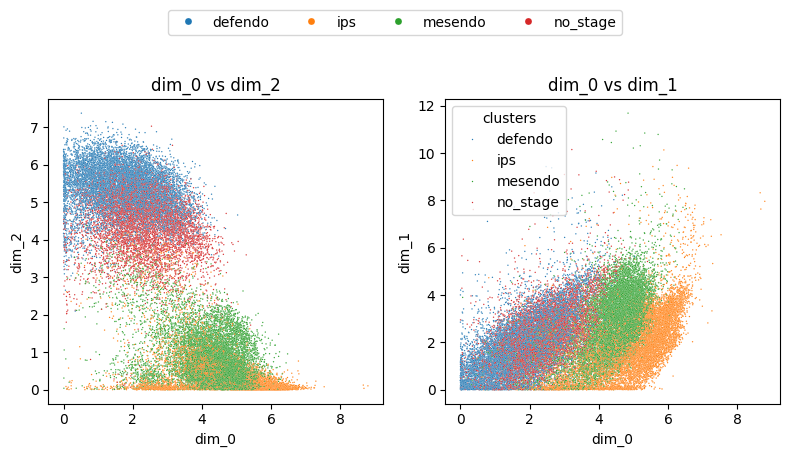

In [19]:
learned_activations = scvi_palava.get_latent_representation()
plot_df = pd.DataFrame({
        f'dim_0': learned_activations[:,0].flatten(),
        f'dim_1': learned_activations[:,1].flatten(),
        f'dim_2': learned_activations[:,2].flatten(),
       f'dim_unann': learned_activations[:,53+29].flatten(),
    'clusters': adata_norm.obs['cell_differentiation']
    })
fig,axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))  # 2 plots side by side

# First scatterplot (dim_0 vs dim_2)
sns.scatterplot(data=plot_df, x='dim_0', y='dim_2', s=1, hue='clusters', ax=axes[0], rasterized=True)
axes[0].set_title('dim_0 vs dim_2')
axes[0].legend_.remove()  # Optional: remove duplicate legends

# Second scatterplot (dim_0 vs dim_1)
sns.scatterplot(data=plot_df, x='dim_0', y='dim_1', s=1, hue='clusters', ax=axes[1], rasterized=True)
axes[1].set_title('dim_0 vs dim_1')

# Single shared legend
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, 1.05), markerscale = 5)

plt.tight_layout()
plt.show()
plt.close()

83
[1.2520952224731445 1.034031867980957 1.0259419679641724
 0.7627555131912231 0.7502740621566772 0.6170507669448853
 0.5975639820098877 0.5913637280464172 0.5804941058158875
 0.5722986459732056 0.5572890043258667 0.5567636489868164
 0.5541985630989075 0.5485419034957886 0.5087104439735413
 0.4987429082393646 0.4865686893463135 0.4774918258190155
 0.47362586855888367 0.4675523340702057 0.43874892592430115
 0.4286583960056305 0.42758065462112427 0.42182961106300354
 0.41737794876098633 0.390728235244751 0.3845129907131195
 0.3760167956352234 0.35546019673347473 0.35028716921806335
 0.3393653333187103 0.33857446908950806 0.3314827084541321
 0.3232421278953552 0.31848448514938354 0.30568963289260864
 0.29367735981941223 0.289150595664978 0.28780829906463623
 0.28541234135627747 0.2842716872692108 0.28145068883895874
 0.27213937044143677 0.27040597796440125 0.26984402537345886
 0.2694464325904846 0.26696768403053284 0.2661800980567932
 0.2637540400028229 0.2625161111354828 0.2550956308841

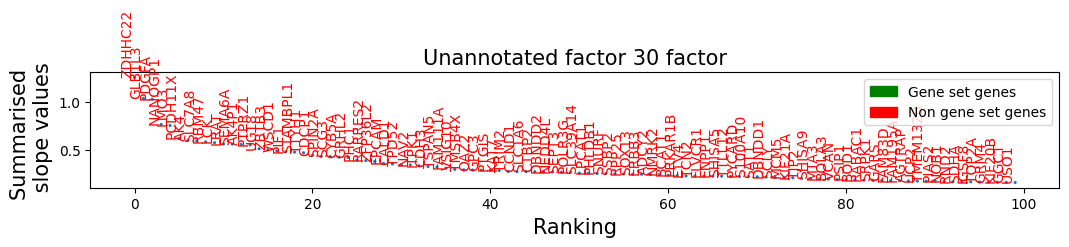

['ZDHHC22', 'GLB1L3', 'PDGFA', 'NANOGP1', 'LMO3', 'PCDH11X', 'AK4', 'SLC7A8', 'RBM47', 'LCK', 'LRAT', 'SEMA6A', 'AK4P1', 'PTPRZ1', 'UGT8', 'ZBTB3', 'WSCD1', 'PIF1', 'STAMBPL1', 'TTYH1', 'CDCP1', 'SPIN2A', 'SCG3', 'CYB5A', 'GRHL2', 'PHC1', 'RARRES2', 'ZFP36L2', 'EPCAM', 'CALD1', 'TPD52', 'NAV2', 'ITPK1', 'CDH3', 'TSPAN5', 'FAM111A', 'VSIG10', 'TMSB4X', 'OAZ2', 'GPC3', 'PTGIS', 'KAT7', 'TRIM2', 'CCND1', 'SLC1A6', 'CTBP2', 'DBNDD2', 'NEDD4L', 'SEPT3', 'POLR3G', 'SLC39A14', 'LPCAT1', 'PHLDB1', 'SNURF', 'SSBP2', 'RPP25', 'SOX13', 'ERBB3', 'ADCY2', 'NMRK2', 'BCAT1', 'PRKAR1B', 'ETV4', 'TCN2', 'FLVCR1', 'ENPP1', 'SHISA5', 'TTLL12', 'PYCARD', 'S100A10', 'SAT1', 'DBNDD1', 'SCLY', 'MCM5', 'KIF21A', 'TJP2', 'SHISA9', 'MTA3', 'BOLA3', 'VCAN', 'PSIP1', 'BOD1', 'RABAC1', 'SRPK1', 'GARS', 'FAM83D', 'FAM195A', 'AGTRAP', 'UCP2', 'TMEM132B', 'PIAS2', 'NOB1', 'RND2', 'SDHA', 'IGSF8', 'TOP2A', 'GRM4', 'KIF20B', 'GGCT', 'USO1']
64
[0.47651931643486023 0.44667017459869385 0.44280895590782166
 0.427192538976

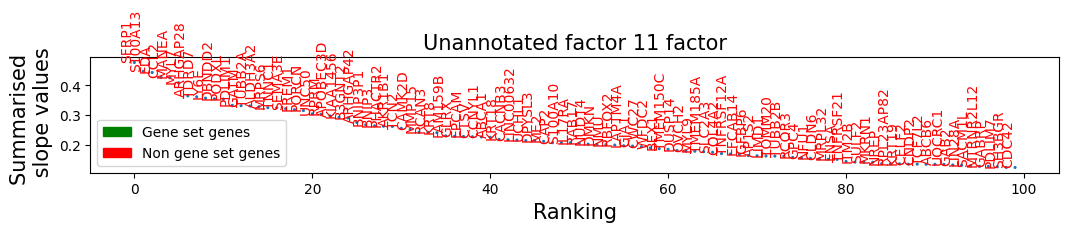

['SFRP1', 'S100A13', 'EDA', 'CCL2', 'MANEA', 'MYL7', 'ARHGAP28', 'TDRD7', 'LY6E', 'DBNDD2', 'PODXL', 'PDLIM1', 'GATM', 'TUBB2A', 'ALDH3A2', 'MRPS6', 'TNNC1', 'SEMA3E', 'FREM1', 'PORCN', 'UNC50', 'RPRM', 'APOBEC3D', 'KIAA1456', 'B3GNT2', 'ARHGAP42', 'BNIP3P1', 'BNIP3', 'PHACTR2', 'AKR1B1', 'TCN2', 'CAMK2D', 'MMP15', 'RCAN3', 'KRT8', 'FAM159B', 'GLRX', 'EPCAM', 'CTSV', 'CCNYL1', 'ABCA1', 'KRT18', 'CACNB3', 'LINC00632', 'UCHL1', 'DPYSL3', 'ME2', 'CAP2', 'S100A10', 'IL17RA', 'RAB17', 'NUDT4', 'DMKN', 'NMU', 'RBFOX2', 'LAPTM4A', 'GJA1', 'CWC27', 'WFDC2', 'BEX1', 'TMEM150C', 'DUSP14', 'OVCH2', 'MYL9', 'TMEM185A', 'SLC2A3', 'COL4A2', 'TNFRSF12A', 'EFCAB14', 'IGFBP6', 'AP1S2', 'LIMD1', 'TOMM20', 'TUBB2B', 'RCOR3', 'GPC4', 'NFU1', 'CLDN6', 'MRPL32', 'ENSA', 'TNFRSF21', 'ITM2B', 'SULF2', 'MKRN1', 'NREP', 'RPL23AP82', 'KRT19', 'CELF2', 'CNDP2', 'TCF7L2', 'ABCB6', 'UQCRC1', 'GAB2', 'LIN28A', 'SACM1L', 'MTRNR2L12', 'GABRP', 'PDLIM7', 'SH3BGR', 'CDC42']
0
[0.6269886493682861 0.543654203414917 0.5332

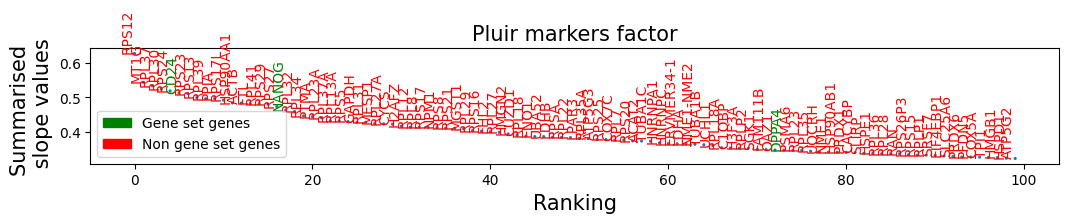

['RPS12', 'MT1G', 'RPL37', 'RPL30', 'RPS24', 'CD24', 'RPS23', 'RPS13', 'RPL39', 'PPIA', 'RPS17L', 'HSP90AA1', 'ACTB', 'FTL', 'RPL41', 'RPS29', 'RPS27', 'NANOG', 'RPL32', 'RPL34', 'PTMA', 'RPL23A', 'RPL37A', 'RPL13A', 'RPS5', 'GAPDH', 'RPL31', 'MESP1', 'RPL27A', 'CYCS', 'H2AFZ', 'RPL12', 'RPL8', 'RPS17', 'NPM1', 'RPS8', 'RPS21', 'MGST1', 'RPL29', 'RPS16', 'FHL2', 'RPL27', 'HMGN2', 'CUZD1', 'RPL18', 'ENO1', 'UBA52', 'LDHB', 'RPSA', 'RPL22', 'LPAR3', 'RPL35A', 'ATP5G3', 'RPS25', 'COX7C', 'RPL7', 'RPS20', 'ACAT2', 'TUBA1C', 'HNRNPA1', 'HNRNPC', 'ERVMER34-1', 'LDHA', 'NME1-NME2', 'TUBA1B', 'UCHL1', 'RPL18A', 'C1QBP', 'H3F3A', 'RPLP2', 'SGK1', 'FAM111B', 'OAZ1', 'DPPA4', 'PSMA6', 'RPL23', 'RPL35', 'UQCRH', 'NME1', 'HSP90AB1', 'PRDX1', 'CACYBP', 'SLIRP', 'HSPE1', 'RPL36', 'RPL28', 'RAN', 'RPS26P3', 'RPS15', 'RPLP1', 'SRSF7', 'EIF4EBP1', 'SLC25A6', 'PRDX6', 'PFDN5', 'COX5A', 'TPI1', 'HMGB1', 'HSPD1', 'ATP5G2']
1
[0.5570915341377258 0.3821689784526825 0.37139299511909485
 0.3182987868785858 0.3

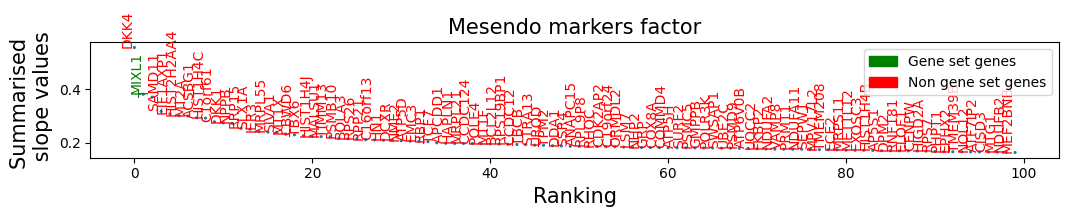

['DKK4', 'MIXL1', 'T', 'SAMD11', 'EIF1AXP1', 'HIST2H2AA4', 'MT2A', 'ACSBG1', 'HIST1H4C', 'C1orf61', 'DKK1', 'NPPB', 'RRP15', 'SLX1A', 'IER3', 'MRPL55', 'SIVA1', 'MT1X', 'CBWD6', 'TBX6', 'HIST1H4J', 'MALSU1', 'TIMM13', 'PSMB10', 'BOLA3', 'RPS26', 'RPP21', 'C16orf13', 'HN1', 'DCXR', 'NME2', 'ATP5D', 'EMC3', 'RBP1', 'TCF7', 'APCDD1', 'HAPLN1', 'MRPL21', 'CCDC124', 'POLE4', 'MT1F', 'BCL2L12', 'RPS19BP1', 'CCDC12', 'TBCB', 'STRA13', 'UROD', 'TPM2', 'DDA1', 'SSR4', 'ANAPC15', 'RPL9P8', 'RHOC', 'CDK2AP2', 'C19orf24', 'ORMDL2', 'LSM7', 'NHP2', 'GRP', 'COX8A', 'COMMD4', 'ATP5H', 'SURF2', 'PSMC5', 'GMPPB', 'POLR3K', 'SWSAP1', 'UBE2C', 'PSMD9', 'ATP6V0B', 'UQCC2', 'FKBP2', 'NDUFA2', 'VAMP8', 'PRMT1', 'NDUFA11', 'SEPW1', 'MPV17L2', 'TMEM208', 'ECE2', 'MRPS11', 'METTL12', 'EXOSC3', 'HIST1H4B', 'AP5S1', 'DPM2', 'RNF181', 'ELOF1', 'CENPW', 'HIGD2A', 'RPS7', 'PHPT1', 'EPHX2', 'TMEM39B', 'NOL12', 'ATF7IP2', 'CISD3', 'MTG1', 'NDUFB2', 'MEF2BNB']
2
[1.041512370109558 0.8707501292228699 0.8621548414230347

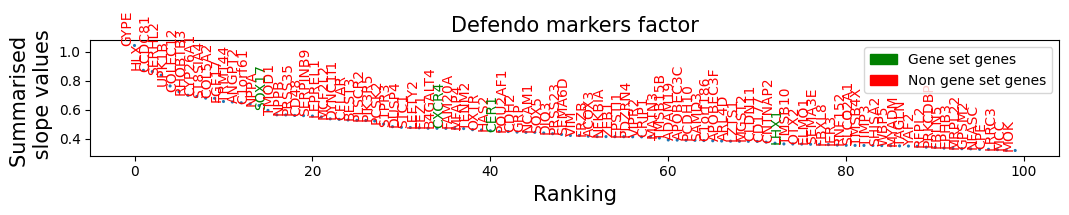

['GYPE', 'HLX', 'CCDC81', 'SERHL2', 'UPK1B', 'COLEC12', 'RHOBTB3', 'CYP26A1', 'ST8SIA4', 'COL5A2', 'FGF17', 'TRMT44', 'ANGPT2', 'C1orf61', 'NPPA', 'SOX17', 'TMOD1', 'NPPB', 'PRSS35', 'CD48', 'SERPINB9', 'LEPREL1', 'MCF2L2', 'DYNC1I1', 'CFLAR', 'BEST3', 'PLSCR2', 'PIK3R5', 'PCSK2', 'S1PR3', 'DUSP4', 'STC1', 'LEFTY2', 'FEZ1', 'B4GALT4', 'CXCR4', 'FAM20A', 'MFAP4', 'TENM2', 'OXTR', 'HAS2', 'CER1', 'POU2AF1', 'CDH2', 'GRP', 'NCAM1', 'SOX5', 'DIO3', 'PRSS23', 'SEMA6D', 'VIM', 'FRZB', 'ACOX3', 'NFKBIA', 'ZEB1', 'EPSTI1', 'PDZRN4', 'VIPR2', 'CRIP1', 'MATN3', 'TMSB15B', 'ADAM19', 'APOBEC3C', 'PCDH10', 'SAMD3', 'C1orf186', 'APOBEC3F', 'ARL4D', 'LZTS1', 'MGST2', 'CLDN11', 'CD177', 'CNTNAP2', 'LHX1', 'TMSB10', 'OTX2', 'ELMO1', 'SEMA3E', 'FBXL8', 'IER3', 'RNF152', 'SLCO2A1', 'TMSB4X', 'TIMP3', 'SHISA2', 'WBP5', 'MYADM', 'TAGLN', 'YAF2', 'RFPL2', 'PRKCDBP', 'FBLN5', 'EPHB3', 'MRPL22', 'GPSM2', 'NFASC', 'CPE', 'LRRC3', 'MCC', 'MOK']
3
[2.9690191745758057 2.800811290740967 2.7760167121887207
 2.50277

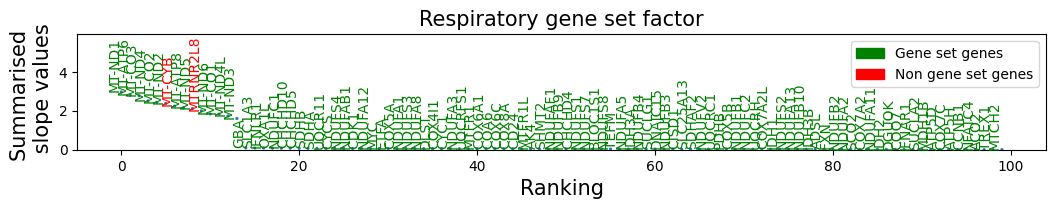

['MT-ND1', 'MT-ATP6', 'MT-CO3', 'MT-ND4', 'MT-CO2', 'MT-ND2', 'MT-CYB', 'MT-ATP8', 'MT-ND5', 'MTRNR2L8', 'MT-ND6', 'MT-CO1', 'MT-ND4L', 'MT-ND3', 'GBA', 'SLC1A3', 'IFNLR1', 'OXA1L', 'NDUFC1', 'CHCHD10', 'CHCHD5', 'SDHB', 'SDHA', 'UQCR11', 'CYCS', 'NDUFS4', 'NDUFAB1', 'CDK1', 'NDUFA12', 'MYC', 'ETFA', 'COX5A', 'NDUFA1', 'NDUFS3', 'NDUFA8', 'DLST', 'COX4I1', 'CYC1', 'NDUFA3', 'UQCRFS1', 'MTFR1', 'COX6A1', 'COA6', 'COX6C', 'COX8A', 'CD24', 'MTFR1L', 'AK4', 'SHMT2', 'NDUFAF1', 'NDUFB9', 'CHCHD4', 'NDUFS1', 'NDUFS7', 'BLOC1S1', 'NDUFS8', 'TEFM', 'NDUFA5', 'IDH3A', 'NDUFB4', 'SUCLG1', 'DNAJC15', 'NDUFB3', 'CISD1', 'SLC25A13', 'SDHAF2', 'NDUFV2', 'UQCRC1', 'PDHB', 'COX5B', 'NDUFB1', 'NDUFC2', 'UQCRH', 'COX7A2L', 'IDH1', 'NDUFS2', 'NDUFA13', 'NDUFB10', 'IDH3B', 'ADSL', 'FXN', 'NDUFB2', 'NDUFA2', 'SCO2', 'COX7A2', 'NDUFA11', 'IDH2', 'DGUOK', 'COQ7', 'IFNAR1', 'SUCLA2', 'MDH1B', 'ATP5D', 'COX7C', 'ATP5H', 'CCNB1', 'NFATC4', 'ACO2', 'TREX1', 'MTCH2']
12
[0.016957970336079597 0.012808050960302353 

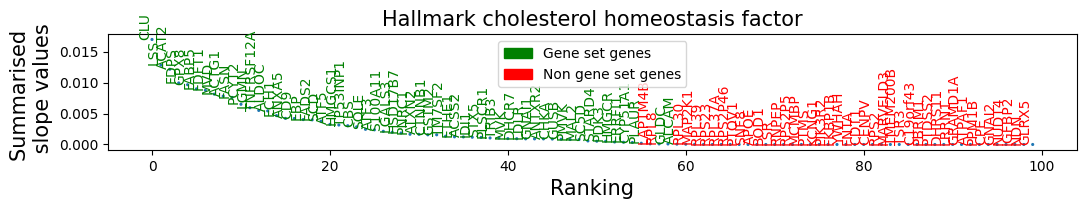

['CLU', 'LSS', 'ACAT2', 'FDPS', 'GPX8', 'FABP5', 'FDFT1', 'MVD', 'ACTG1', 'FASN', 'PCYT2', 'LGMN', 'TNFRSF12A', 'ALDOC', 'ECH1', 'ANXA5', 'CD9', 'EBP', 'FADS2', 'SCD', 'ATF5', 'HMGCS1', 'TP53INP1', 'CBS', 'SQLE', 'ATF3', 'S100A11', 'LGALS3', 'HSD17B7', 'PNRC1', 'ATXN2', 'CTNNB1', 'GSTM2', 'TM7SF2', 'ETHE1', 'ACSS2', 'IDI1', 'STX5', 'PLSCR1', 'TRIB3', 'MVK', 'DHCR7', 'LDLR', 'GNAI1', 'ANTXR2', 'CHKA', 'GUSB', 'PMVK', 'MAL2', 'SC5D', 'STARD4', 'PDK3', 'HMGCR', 'ERRFI1', 'CYP51A1', 'PLAUR', 'LAPTM4B', 'RPL8', 'GLDC', 'ALCAM', 'RPL30', 'MAP2K1', 'RPL39', 'RPS23', 'RPL37A', 'RPS2P46', 'PTOV1', 'SNF8', 'APOE', 'BOD1', 'LSR', 'RNPEP', 'RPS2P5', 'MCMBP', 'PTMS', 'KCNG1', 'PIK3R2', 'FKBP1B', 'YWHAH', 'FNTA', 'CDT1', 'CENPV', 'RPS2', 'MARVELD3', 'TMEM200B', 'TSR3', 'C19orf43', 'PBRM1', 'PTDSS2', 'DHRS11', 'LRRN1', 'GRAMD1A', 'ATPAF1', 'PPM1B', 'CPE', 'GNAI2', 'NUDT4', 'IGFBP2', 'NDN', 'GLRX5']
21
[1.3701575994491577 1.1907440423965454 1.149685025215149
 1.0208286046981812 0.9899072051048279 0.98

KeyboardInterrupt: 

In [32]:

gene_names = adata.var
num_genes = len(adata.var)

pathways_bool = pathways
path_uann =  torch.zeros(num_genes)
dict_for_co_ocurrence ={}

for fac in [83, 64,  0,1,2,3,12,21,16]:#np.argsort(factor_importance[:54])[::-1][:20]:
        print(fac)
        factors = [fac]

        slopes_for_all_fac_lst = scvi_palava.spline_approach(factors = factors)
        slopes_for_all_fac  = {i:j for i, j  in zip(factors,slopes_for_all_fac_lst)}
        


        data_1 = np.quantile(abs(slopes_for_all_fac[fac]), q=0.95, axis=0)
        if fac <50:
            gene_set = pathways_bool[fac].numpy()[None]
        else: 
            gene_set =np.zeros((1,9000))
        data_1_and_de_no_error = np.concatenate((data_1[None],gene_set ,gene_names.index.to_numpy()[None]), axis=0)
        data_1_and_de_no_error = sort_based_on_first_row(data_1_and_de_no_error)
    
        n_top_genes = 100
    
        y = data_1_and_de_no_error[0][:n_top_genes]
        x = np.array([i for i in range(n_top_genes)])
        top_gene_names = [element for element in data_1_and_de_no_error[2][:n_top_genes]]
    

        plt.figure(figsize=(12.5, 1.5))
        plt.scatter(x, y, s = 5, edgecolor='none')
        print(y)
        # plotting pathway genes
        pathway_gene_ind = data_1_and_de_no_error[1][:n_top_genes] == 1
        
        plt.xlabel('Ranking', fontsize =15)
        plt.ylabel('Summarised \n slope values', fontsize =15)
        plt.title(pathway_names_plot[fac].split('[')[0]+ 'factor', fontsize =15)
        
        
        
        top_gene_names = [element.split('_')[1] for element in data_1_and_de_no_error[2][:n_top_genes]]
        for i, txt in enumerate(top_gene_names):
             color = ['r', 'g'][int(data_1_and_de_no_error[1][i])]      
             plt.annotate(txt, (x[i], y[i]), ha = 'right', va = 'bottom', rotation = 90, fontsize = 10, color = color)
        geneset = mpatches.Patch(color='g', label='Gene set genes')
        nongeneset = mpatches.Patch(color='r', label='Non gene set genes')
        if 'Resp' in pathway_names_plot[fac]: # Resp genes have long name
            plt.ylim(0,np.max(y) * 2)
        plt.legend(handles=[geneset, nongeneset])
        plt.show()
        plt.close()
        print(np.array(top_gene_names)[:n_top_genes].tolist())
        count = 0 
        dict_for_co_ocurrence[pathway_names_plot[fac]] = np.array(top_gene_names)[:n_top_genes].tolist()


In [33]:
for i, gene in enumerate(adata.var.index):
    if 'VSNL1' in gene:
        print(gene, i)
        print(spearmanr(adata_norm.X[:,i].flatten(), adata_norm.obsm['pseudo']))
    if 'GYPB' in gene:
        print(gene, i)
        print(spearmanr(adata_norm.X[:,i].flatten(), adata_norm.obsm['pseudo']))
    if 'NANOGP1' in gene:
        print(gene, i)
        print(spearmanr(adata_norm.X[:,i].flatten(), adata_norm.obsm['pseudo']))
    if 'ZDHHC22' in gene:
        print(gene, i)
        print(spearmanr(adata_norm.X[:,i].flatten(), adata_norm.obsm['pseudo']))

    if 'GLB1L3' in gene:
        print(gene, i)
        print(spearmanr(adata_norm.X[:,i].flatten(), adata_norm.obsm['pseudo']))

    if 'S100A13' in gene:
        print(gene, i)
        print(spearmanr(adata_norm.X[:,i].flatten(), adata_norm.obsm['pseudo']))



ENSG00000163032_VSNL1 5648
SignificanceResult(statistic=np.float64(-0.7774666394296931), pvalue=np.float64(0.0))
ENSG00000166105_GLB1L3 6022
SignificanceResult(statistic=np.float64(-0.7245618950595737), pvalue=np.float64(0.0))
ENSG00000176654_NANOGP1 7074
SignificanceResult(statistic=np.float64(-0.5607858849842519), pvalue=np.float64(0.0))
ENSG00000177108_ZDHHC22 7111
SignificanceResult(statistic=np.float64(-0.6568447312464042), pvalue=np.float64(0.0))
ENSG00000189171_S100A13 7930
SignificanceResult(statistic=np.float64(0.15734951768528416), pvalue=np.float64(1.6356958265956525e-198))
ENSG00000250361_GYPB 8876
SignificanceResult(statistic=np.float64(0.6685681743988361), pvalue=np.float64(0.0))


In [28]:
pathway_names_plot

['Pluir markers [0]',
 'Mesendo markers [1]',
 'Defendo markers [2]',
 'Respiratory gene set [3]',
 'Hallmark adipogenesis [4]',
 'Hallmark allograft rejection [5]',
 'Hallmark androgen response [6]',
 'Hallmark angiogenesis [7]',
 'Hallmark apical junction [8]',
 'Hallmark apical surface [9]',
 'Hallmark apoptosis [10]',
 'Hallmark bile acid metabolism [11]',
 'Hallmark cholesterol homeostasis [12]',
 'Hallmark coagulation [13]',
 'Hallmark complement [14]',
 'Hallmark dna repair [15]',
 'Hallmark e2f targets [16]',
 'Hallmark epithelial mesenchymal transition [17]',
 'Hallmark estrogen response early [18]',
 'Hallmark estrogen response late [19]',
 'Hallmark fatty acid metabolism [20]',
 'Hallmark g2m checkpoint [21]',
 'Hallmark glycolysis [22]',
 'Hallmark hedgehog signaling [23]',
 'Hallmark heme metabolism [24]',
 'Hallmark hypoxia [25]',
 'Hallmark il2 stat5 signaling [26]',
 'Hallmark il6 jak stat3 signaling [27]',
 'Hallmark inflammatory response [28]',
 'Hallmark interferon a